# Лабораторная работа №1

Импортируем библиотеки:

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Читаем наш датасет:

In [3]:
df = pd.read_csv("student_lifestyle_100k.csv")
df.head()

,Student_ID,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
0,1001,22,Female,Science,3.50,7.3,3.3,3.4,114,5,False
1,1002,20,Male,Engineering,2.72,5.5,7.2,6.0,142,2,False
2,1003,20,Male,Medical,3.01,5.4,2.3,1.8,137,3,False
3,1004,21,Male,Engineering,3.63,8.1,2.0,4.6,130,3,False
4,1005,19,Male,Arts,3.14,6.8,2.6,4.3,4,6,False


## Этап 1: Проведем разведочный анализ (EDA)

### Проверка типов данных
Во-первых, проверим типы данных всех столбцов, чтобы в дальнейшем предсказуемо с нми работать (строить графики и т.д.):

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Student_ID          100000 non-null  int64  
 1   Age                 100000 non-null  int64  
 2   Gender              100000 non-null  str    
 3   Department          100000 non-null  str    
 4   CGPA                100000 non-null  float64
 5   Sleep_Duration      100000 non-null  float64
 6   Study_Hours         100000 non-null  float64
 7   Social_Media_Hours  100000 non-null  float64
 8   Physical_Activity   100000 non-null  int64  
 9   Stress_Level        100000 non-null  int64  
 10  Depression          100000 non-null  bool   
dtypes: bool(1), float64(4), int64(4), str(2)
memory usage: 7.7 MB


Видим, что типы данных везде соответствуют содержимому (никакое число не записано как строка или что-либо подобное). Также видим, что никто не указал возраст в виде дроби и не оценил свой уровень стресса не целым числом. Кроме того здесь видно, что в датасете нет пропусков, но этим мы займемся позже.

### Некорректные данные
Попытаемся понять, есть ли у нас строки, в которых содержаться некорректные данные, например, отрицательный возраст или CGPA больше 4.0. Для этого посмотрим минимальное и максимальное значение по каждому столбцу:

In [5]:
df.describe()

,Student_ID,Age,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,51000.500000,21.009010,2.898316,6.996425,4.509517,3.503288,74.353180,4.131660
std,28867.657797,2.000382,0.532240,1.498682,1.976076,1.486852,43.366963,1.424151
min,1001.000000,18.000000,1.560000,3.000000,0.000000,0.000000,0.000000,2.000000
25%,26000.750000,19.000000,2.450000,6.000000,3.200000,2.500000,37.000000,3.000000
50%,51000.500000,21.000000,2.900000,7.000000,4.500000,3.500000,74.000000,4.000000
75%,76000.250000,23.000000,3.350000,8.000000,5.800000,4.500000,112.000000,5.000000
max,101000.000000,24.000000,4.000000,12.000000,12.800000,10.000000,149.000000,10.000000


Видим, что все значения лежат в верных даипазонах.

В контексте нашей задачи я также решила найти строки, в которых сумма часов, потраченных на сон, учебу и соц. сети, превышает 24 часа:

In [6]:
print('Количество строк до удаления некорректных значений:', df.shape[0])
cond_valid_sum_hours = (df['Sleep_Duration'] + df['Study_Hours'] + df['Social_Media_Hours']) <= 24
df = df[cond_valid_sum_hours]
print('После:', df.shape[0])

Количество строк до удаления некорректных значений: 100000
После: 99921


Удалилось не очень много значений, но это и хорошо - больше данных для обучения.

### Дубликаты
В нашем датасете у дубликтов будут совпадать даже ID студентов, т.е. это записи об одних и тех же людях, и их дублирование не несет никакой смысловой нагрузки, а только исказит статистику и предсказания модели. Смело их удаляем:

In [7]:
print(f'Количество строк в датасете до удаления дубликатов: {df.shape[0]}')
df.drop_duplicates(inplace=True)
print(f'После: {df.shape[0]}')

Количество строк в датасете до удаления дубликатов: 99921
После: 99921


Количество строк не изменилось, значит дубликатов не было, но провреить это было необходимо.

### Отбор признаков

Далее мы будем решать, какие признаки оставить для обучения модели, а какие - убрать. Сразу же уберем стобец Student_ID, т.к. это по сути случайное значение (студент мог бы иметь другой ID и его жизнь от этого никак не поменялась бы), которое может только запутать нашу модель.

In [8]:
df.drop(columns=['Student_ID'], inplace=True)
df.head()

,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
0,22,Female,Science,3.50,7.3,3.3,3.4,114,5,False
1,20,Male,Engineering,2.72,5.5,7.2,6.0,142,2,False
2,20,Male,Medical,3.01,5.4,2.3,1.8,137,3,False
3,21,Male,Engineering,3.63,8.1,2.0,4.6,130,3,False
4,19,Male,Arts,3.14,6.8,2.6,4.3,4,6,False


#### Визуализация данных
Теперь сделаем визуализацию наших данных. Это даст нам хорошее представление о том, с чем мы вообще работаем, и поможет понять размер набора данных, их распределение, наличие пропусков, дубликатов и аномалий.

Cначала сделаем визуализации для непрерывных числовых признаков. Age и Stress_Level - это дискретные величины, их отдельно визуализируем чуть позже.

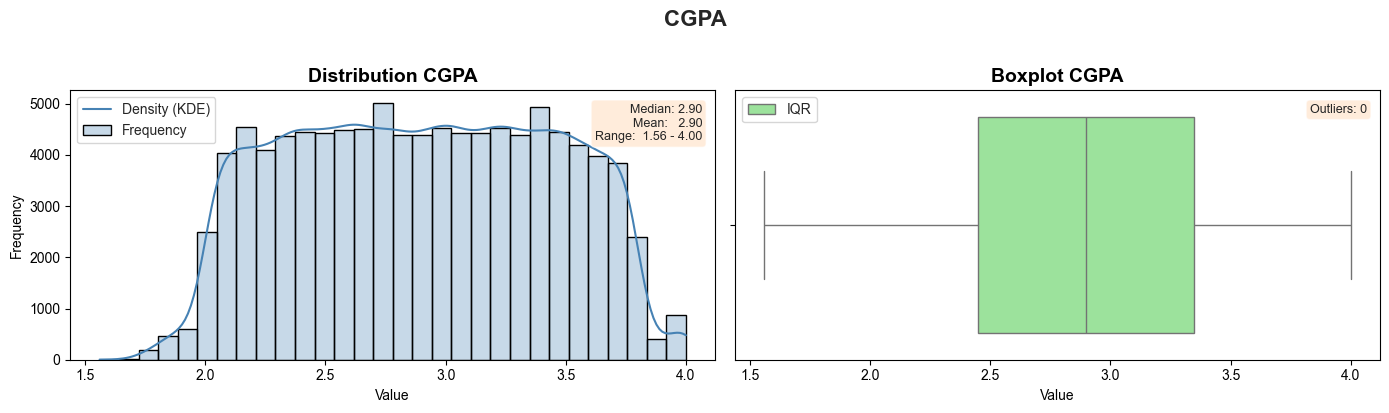

CGPA:
Пропусков: 0
Выбросов: 0


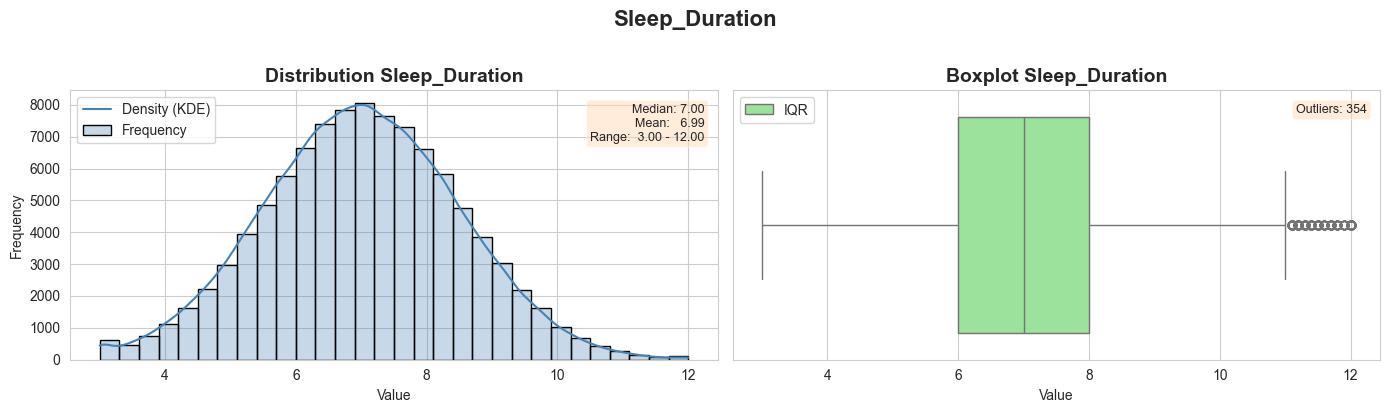

Sleep_Duration:
Пропусков: 0
Выбросов: 354


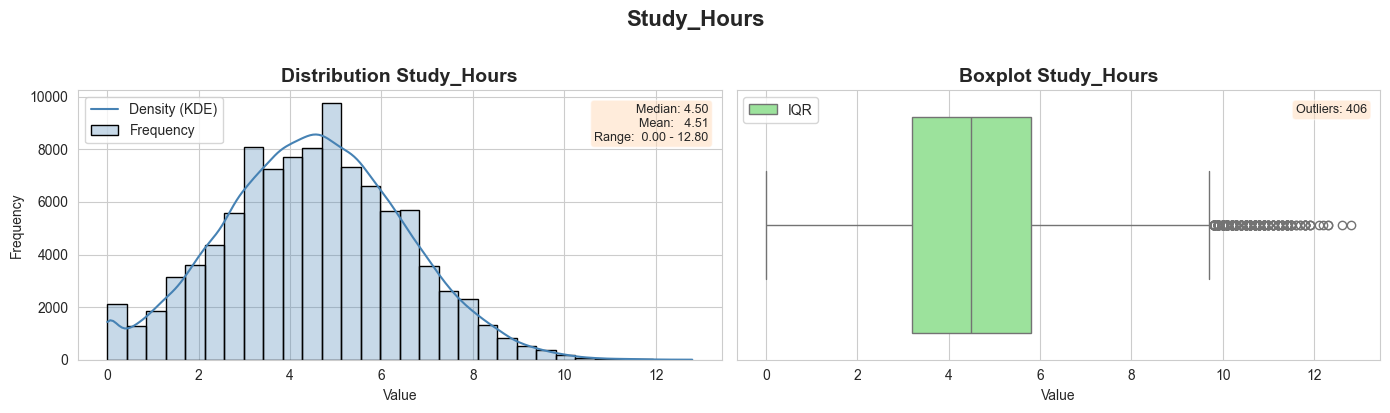

Study_Hours:
Пропусков: 0
Выбросов: 406


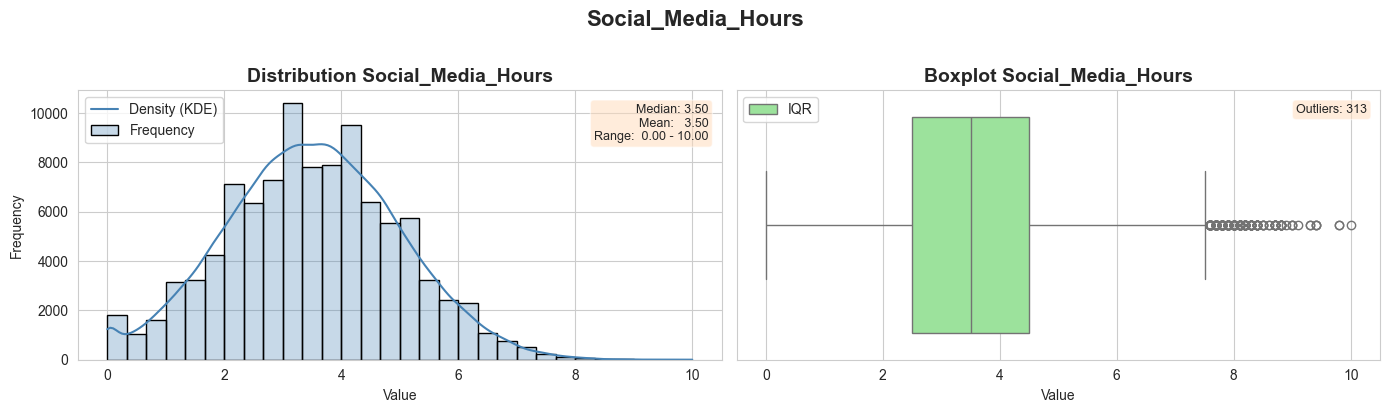

Social_Media_Hours:
Пропусков: 0
Выбросов: 313


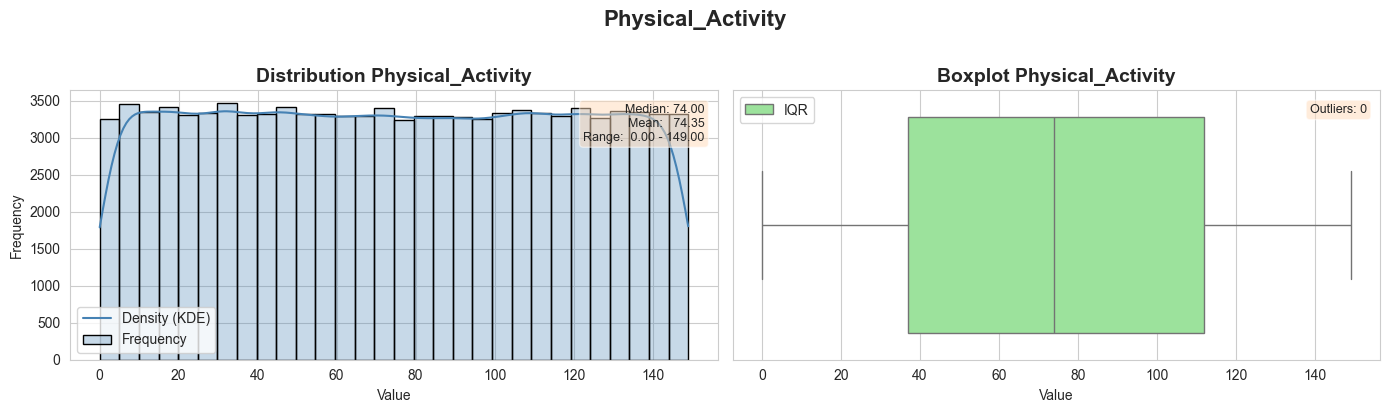

Physical_Activity:
Пропусков: 0
Выбросов: 0


In [9]:
numeric_cols = df.drop(columns=['Age', 'Stress_Level']).select_dtypes(include='number').columns.tolist()

for col in numeric_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    sns.set_style("whitegrid")

    # гистограмма с KDE
    sns.histplot(data=df, x=col, bins=30, kde=True, ax=axes[0],
                    color='steelblue', edgecolor='black', alpha=0.3)
    axes[0].set_title(f'Distribution {col}', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Value')
    axes[0].set_ylabel('Frequency')
    axes[0].legend(['Density (KDE)', 'Frequency'], loc='best')

    # Boxplot (ящик с усами)
    sns.boxplot(data=df, x=col, ax=axes[1], color='lightgreen')
    axes[1].set_title(f'Boxplot {col}', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Value')
    axes[1].legend(['IQR', 'Медиана', 'Выбросы'], loc='best')

    # метрики для гистограммы
    stats_text_hist = (f"Median: {df[col].median():.2f}\n"
                    f"Mean:   {df[col].mean():.2f}\n"
                    f"Range:  {df[col].min():.2f} - {df[col].max():.2f}")

    axes[0].text(0.98, 0.95, stats_text_hist, transform=axes[0].transAxes,
                    fontsize=9, verticalalignment='top', horizontalalignment='right',
                    bbox=dict(boxstyle='round', facecolor='peachpuff', alpha=0.5))

    # считаем выбросы
    col_data = df[col].dropna()

    Q1 = col_data.quantile(0.25)
    Q3 = col_data.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = ((col_data < lower_bound) | (col_data > upper_bound)).sum()
    missing = df[col].isnull().sum()

    # метрика 
    stats_text_bxp = (f"Outliers: {outliers}")

    axes[1].text(0.98, 0.95, stats_text_bxp, transform=axes[1].transAxes,
                    fontsize=9, verticalalignment='top', horizontalalignment='right',
                    bbox=dict(boxstyle='round', facecolor='peachpuff', alpha=0.5))

    plt.suptitle(col, fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    print(f"{col}:")
    print(f"Пропусков: {missing}")
    print(f"Выбросов: {outliers}")

У параметров Age и Stress_Level мало уникальных значений (т.к. это целые числа в очень ограниченном диапазоне), поэтому для них сделаем графики с count plot вместо обычной гистограммы и pie chart для большей наглядности распределения:

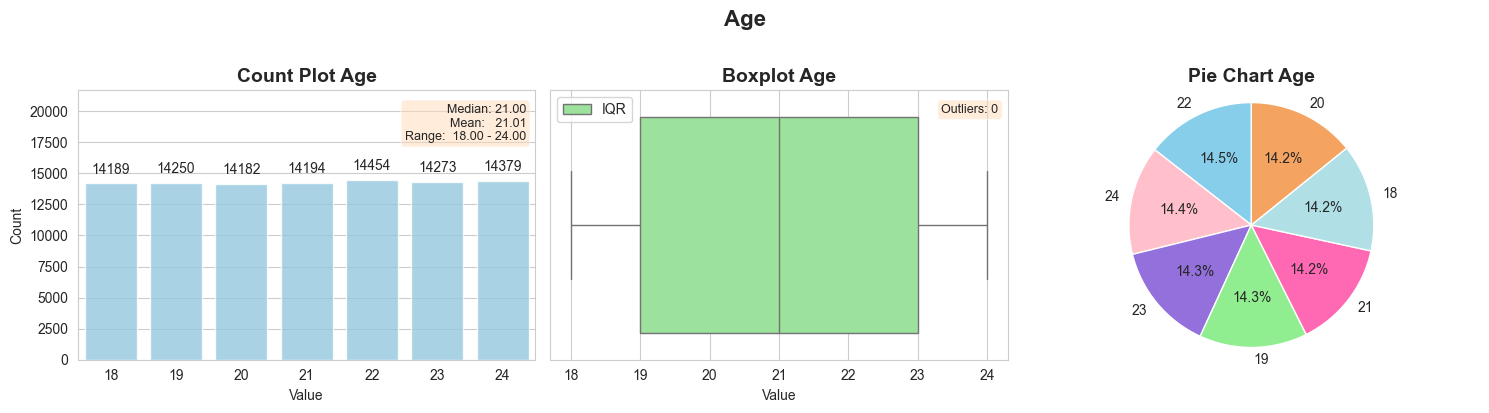

Age:
Пропусков: 0
Выбросов: 0
 18: 14.2002 %
 19: 14.2613 %
 20: 14.1932 %
 21: 14.2052 %
 22: 14.4654 %
 23: 14.2843 %
 24: 14.3904 %


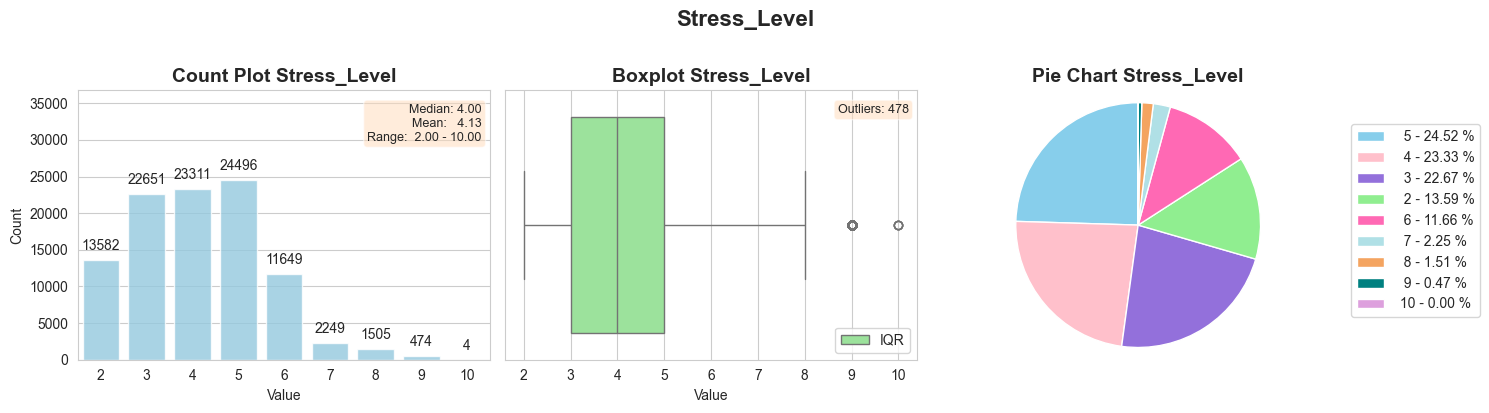

Stress_Level:
Пропусков: 0
Выбросов: 478
  2: 13.5927 %
  3: 22.6689 %
  4: 23.3294 %
  5: 24.5154 %
  6: 11.6582 %
  7: 2.2508 %
  8: 1.5062 %
  9: 0.4744 %
 10: 0.0040 %


In [10]:
for col in ('Age', 'Stress_Level'):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    sns.set_style("whitegrid")
    counted_data = df[col].value_counts()

    # count plot
    sns.countplot(data=df, x=col, ax=axes[0], color='skyblue', alpha=0.8)
    axes[0].set_title(f'Count Plot {col}', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Value')
    axes[0].set_ylabel('Count')
    for p in axes[0].patches:
        axes[0].annotate(f'{int(p.get_height())}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 10), 
                    textcoords='offset points')
    axes[0].set_ylim(bottom=0, top=1.5*counted_data.values.max())

    # Boxplot (ящик с усами)
    sns.boxplot(data=df, x=col, ax=axes[1], color='lightgreen')
    axes[1].set_title(f'Boxplot {col}', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Value')
    axes[1].legend(['IQR', 'Медиана', 'Выбросы'], loc='best')

    # метрики для гистограммы
    stats_text_hist = (f"Median: {df[col].median():.2f}\n"
                       f"Mean:   {df[col].mean():.2f}\n"
                       f"Range:  {df[col].min():.2f} - {df[col].max():.2f}")

    axes[0].text(0.98, 0.95, stats_text_hist, transform=axes[0].transAxes,fontsize=9,
                 verticalalignment='top', horizontalalignment='right',
                 bbox=dict(boxstyle='round', facecolor='peachpuff', alpha=0.5))

    # считаем выбросы
    col_data = df[col].dropna()

    Q1 = col_data.quantile(0.25)
    Q3 = col_data.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = ((col_data < lower_bound) | (col_data > upper_bound)).sum()
    missing = df[col].isnull().sum()

    # метрика 
    stats_text_bxp = (f"Outliers: {outliers}")

    axes[1].text(0.98, 0.95, stats_text_bxp, transform=axes[1].transAxes,
                 fontsize=9, verticalalignment='top', horizontalalignment='right',
                 bbox=dict(boxstyle='round', facecolor='peachpuff', alpha=0.5))

    # pie chart
    autopct = '%1.1f%%' if len(counted_data) <= 7 else None
    labels = counted_data.index if len(counted_data) <= 7 else None
    colors = ['skyblue', 'pink', 'mediumpurple', 'lightgreen', 'hotpink', 'powderblue', 'sandybrown', 'teal', 'plum']
    axes[2].pie(counted_data.values, labels=labels,
    colors=colors, autopct=autopct, startangle=90)
    axes[2].axis('equal')
    legend_data = [f'{name:3} - {(amount / counted_data.values.sum() * 100):1.2f} %' for name, amount in zip(counted_data.index, counted_data.values)]
    if not autopct:
        plt.legend(legend_data, bbox_to_anchor=(1, 0.9) , loc='best')
    axes[2].set_title(f'Pie Chart {col}', fontsize=14, fontweight='bold')

    plt.suptitle(col, fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    print(f"{col}:")
    print(f"Пропусков: {missing}")
    print(f"Выбросов: {outliers}")
    print(*sorted([f'{name:3}: {(amount / counted_data.values.sum() * 100):2.4f} %' for name, amount in zip(counted_data.index, counted_data.values)]), sep='\n')

И для категориальных признаков сделаем bar plot и pie chart:

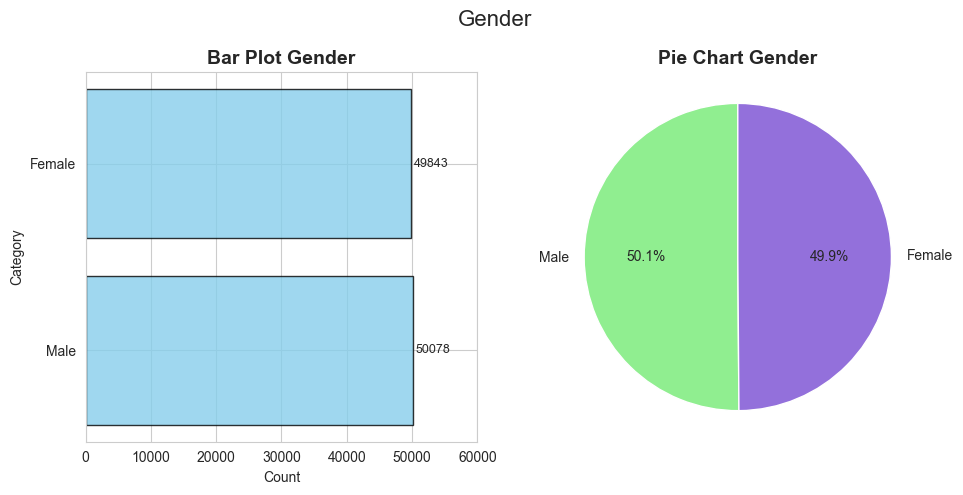

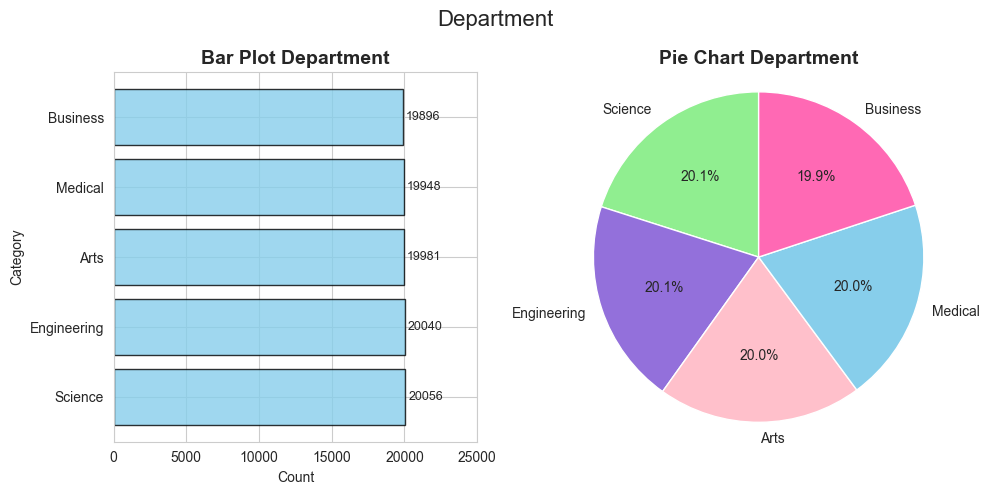

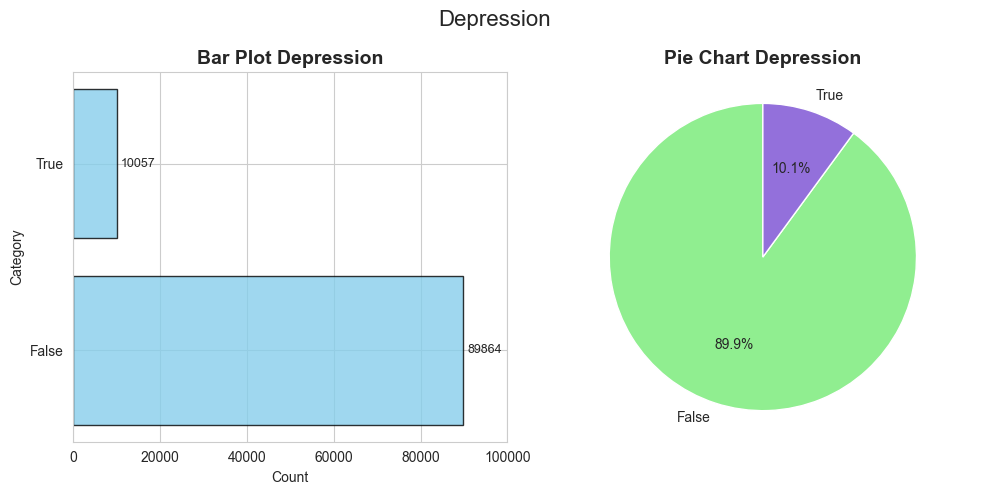

In [11]:
cat_columns = df.select_dtypes(include=['str', 'bool']).columns.tolist()

for col in cat_columns:
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    sns.set_style("whitegrid")
    counted_data = df[col].value_counts()

    # bar plot
    bars = axes[0].barh(counted_data.index, counted_data.values,
                        color='skyblue', edgecolor='black', alpha=0.8)
    axes[0].set_title(f'Bar Plot {col}', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Count')
    axes[0].set_ylabel('Category')
    
    for bar in bars:
       width = bar.get_width()
       axes[0].text(width + max(counted_data.values) * 0.01,
                     bar.get_y() + bar.get_height()/2,
                     f'{int(width)}',
                     va='center', fontsize=9)
    xlims = {
        'Gender': 60000,
        'Department': 25000,
        'Depression': 100000
    }
    axes[0].set_xlim(0, xlims[col])
    if col == 'Depression':
        axes[0].set_yticks([0, 1], ['False', 'True'])

    # pie chart
    axes[1].pie(counted_data.values, labels=counted_data.index,
           colors=['lightgreen', 'mediumpurple', 'pink', 'skyblue', 'hotpink'],
           autopct='%1.1f%%', startangle=90)
    axes[1].axis('equal')
    axes[1].set_title(f'Pie Chart {col}', fontsize=14, fontweight='bold')
    
    
    plt.suptitle(col, fontsize=16)
    plt.tight_layout()
    plt.show()

### Выводы из графиков
1) Видим, что в датасете нет пропусков.

2) Большинство признаков имеют либо нормальное, либо равномерное распределение, нет признаков с дисперсией, близкой к 0 (если бы были, мы бы скорее всего не использовали их для обучения).

3) В классе Depression есть дисбаланс классов, поэтому у нас могут возникнуть проблемы с тем, что модель хорошо предсказывает только мажорный класс. Чтобы не допустить этого, будем сохранять одинаковое соотношение классов в обучающей и тестовой выборке, при обуении настроим веса классов (с помощью class_weight='balanced'), а также подумаем над порогом исходя из того, что нам важнее: найти всех, у кого точно есть депрессия, или найти всех, у кого есть подозрения на нее. Ну и мтерики будем оценивать тоже исходя их этого.

4) Можем оценить содержание и количество выбросов/аномалий. В нашем случае это скорее именно аномалии, т.к. все ответы вполне валидные, но есть просто редкие значения. Поскольку мы будем использовать именно линейные модели, которые очень чувствительны к аномальным значениям, нам нужно их хорошо обработать. Этим сейчас и займемся.

### Обработка выбросов и аномалий



Во-первых, обработаем аномалии в столбце Stress_Level. Интуитивно кажется, что он будет очень влиять на как минимум 1 из наших таргетов - депрессию, что делает его очень важным признаком для нас. При этом у нас всего около 500 ответов '9' и всего 4 ответа '10', что довльно странно. Для начала попытаемся понять, как уровень стресса влияет на таргеты:

In [13]:
stress_stats = df.groupby('Stress_Level').agg({
    'CGPA': 'mean',    # средняя успеваемость
    'Depression': 'mean'    # доля депрессий
}).round(3)

print(stress_stats)

               CGPA  Depression
Stress_Level                   
2             2.906       0.088
3             2.897       0.091
4             2.904       0.094
5             2.900       0.095
6             2.887       0.101
7             2.872       0.123
8             2.849       0.418
9             2.870       0.422
10            3.315       1.000


Видим следующее:
- Успеваемость:

Она примерно одинаковая при уровне стресса от 2 до 9, а на 10 резко повышается. Можем сделать следующее: для предсказывания успеваемости удалим строки с 10 в столбце Stress_Level. Их всего 4, поэтому мы почти не уменьшим набор данных для обучения.

Другой вариант: можно также попробовать сделать отдельный столбец Extreme_stress, отражающий наличие экстремально высоко уровня стресса. У студентов с уровнем стресса 10 будет значение True, у остальных - False. Но из-за слишком маленького набора данных с десяткой есть большой риск переобучения. Модель может запомнить, что в нашем датасете уровень стресса 10 невероятно влияет на резульатат, но возможно это просто случаное совпадение в нашем датасете и в реальной ситуации эффект не настолько гигантский. Поэтому пока просто удалим (ради эксперимента можно будет потом попробовать вариант с доп. столбцом).

- Доля депрессии:

Она равномерно растет с уровнем стресса от 2 до 7 и резко повышается при 8. При уровне стресса 10 депрессия оказывается вообще у всех, но мне кажется, что не стоит делать из этого большие выводы, т.к. у нас всего лишь 4 человека с таким уровнем стресса и это может быть просто совпадением. Поэтому будем ориентироваться именно на скачок при уровне стресса на 8. Я думаю, что хорошо будет создать бинарный признак High_Stress, равный 0 при уровне стресса <=7 и равный 1 при >=8, он хорошо отражает резкий скачок доли депрессий. Если мы одновременно будем использовать High_Stress и оставим Stress_Level, то получим мультиколлиниарные признаки, что испортит показания модели. Если мы удалим Stress_Level, то потеряем ещё 1 важный паттерн: при росте уровня стресса с 2 до 7 доля депрессий равномерно растет. Так что попытаемся сохранить оба паттерна: скачок на '8' и линейное возрастание депрессии на '2'-'7', при этом не делая их мультиколлинеарными. Сделаем так: для предсказания депрессии создадим новый бинарный признак High_Stress, а значения в Stress_Level, равные 8 и выше, заменим на 7, тогда на 7 будет как 0, так и 1 у High_Stress.

Оба паттерна сохранены, но мультиколлиниарности быть не должно. Такой вот feature-engineering :\)

Создадим 2 отдельный датафрейма для первой задачи (про успеваемость) и для второй (депрессия):

In [19]:
df_1 = df[df['Stress_Level'] <= 9].copy()
df_1.describe() # проверяем корректность изменений


,Age,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level
count,99917.000000,99917.000000,99917.000000,99917.000000,99917.000000,99917.000000,99917.000000
mean,21.008857,2.898229,6.994410,4.505713,3.501164,74.353644,4.131269
std,2.000398,0.532170,1.496842,1.972024,1.485030,43.363026,1.423694
min,18.000000,1.560000,3.000000,0.000000,0.000000,0.000000,2.000000
25%,19.000000,2.450000,6.000000,3.200000,2.500000,37.000000,3.000000
50%,21.000000,2.900000,7.000000,4.500000,3.500000,74.000000,4.000000
75%,23.000000,3.350000,8.000000,5.800000,4.500000,112.000000,5.000000
max,24.000000,4.000000,12.000000,12.800000,10.000000,149.000000,9.000000


In [20]:
df_2 = df.copy()
df_2['Stress_Modified'] = df_2['Stress_Level'].clip(upper=7)
df_2['High_Stress'] = (df_2['Stress_Level'] >= 8).astype(int)
df_2 = df_2.drop(columns=['Stress_Level'])
df_2.describe() # проверяем корректность изменений

,Age,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Modified,High_Stress
count,99921.000000,99921.000000,99921.000000,99921.000000,99921.000000,99921.000000,99921.000000,99921.000000
mean,21.008887,2.898246,6.994291,4.505956,3.501174,74.352458,4.106834,0.019846
std,2.000381,0.532189,1.496934,1.972359,1.485036,43.363229,1.360760,0.139471
min,18.000000,1.560000,3.000000,0.000000,0.000000,0.000000,2.000000,0.000000
25%,19.000000,2.450000,6.000000,3.200000,2.500000,37.000000,3.000000,0.000000
50%,21.000000,2.900000,7.000000,4.500000,3.500000,74.000000,4.000000,0.000000
75%,23.000000,3.350000,8.000000,5.800000,4.500000,112.000000,5.000000,0.000000
max,24.000000,4.000000,12.000000,12.800000,10.000000,149.000000,7.000000,1.000000


Другие признаки с аномалиями: Sleep_Duration, Study_Hours и Social_Media_Hours. В них также нет некорректных значений, только очень редкие. Можно попробовать просто удалить их, т.к. суммарно это окло 1500 строк, т.е. всего 1,5% датасета, что довольно мало. Можно попробовать заменить эти аномальные значения на максимальные неаномальные, но это по сути ложные данные, искажающие статистику, и с реальным данными модель тогда будет справляться плохо. Пока оставим их, если показания модели будут плохими, то удалим и посмотрим, что изменилось.

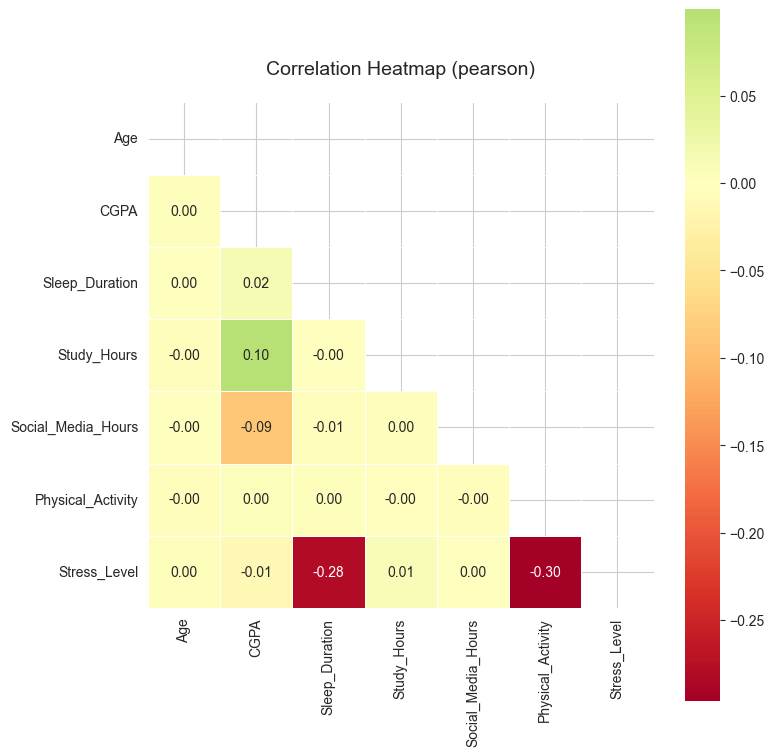


📊 Корреляции с 'CGPA' (по убыванию |r|):
  Study_Hours         : +0.099
  Social_Media_Hours  : -0.088
  Sleep_Duration      : +0.015
  Stress_Level        : -0.012
  Physical_Activity   : +0.005
  Age                 : +0.003


,Age,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level
Age,1.000000,0.003248,0.001205,-0.004015,-0.000428,-0.003691,0.002952
CGPA,0.003248,1.000000,0.015115,0.099485,-0.088322,0.004933,-0.012272
Sleep_Duration,0.001205,0.015115,1.000000,-0.000275,-0.005376,0.003203,-0.282099
Study_Hours,-0.004015,0.099485,-0.000275,1.000000,0.002373,-0.002019,0.008266
Social_Media_Hours,-0.000428,-0.088322,-0.005376,0.002373,1.000000,-0.004922,0.001909
Physical_Activity,-0.003691,0.004933,0.003203,-0.002019,-0.004922,1.000000,-0.296496
Stress_Level,0.002952,-0.012272,-0.282099,0.008266,0.001909,-0.296496,1.000000


In [21]:
def plot_correlation_heatmap(df, target_col=None, method='pearson', threshold=0.7):
    """
    Построение heatmap корреляций + анализ связей с таргетом

    Parameters:
    -----------
    df : pd.DataFrame
    target_col : str, optional — имя целевой переменной
    method : str — 'pearson', 'spearman', 'kendall'
    threshold : float — порог для выделения сильных корреляций
    """
    numeric = df.select_dtypes(include=[np.number])
    corr = numeric.corr(method=method)

    # Heatmap
    plt.figure(figsize=(8, 8))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
                center=0, square=True, linewidths=0.5)
    plt.title(f'Correlation Heatmap ({method})', fontsize=14, pad=20)
    plt.tight_layout()
    plt.show()

    # Если есть таргет — показываем корреляции с ним
    if target_col and target_col in corr.columns:
        target_corr = corr[target_col].drop(target_col).sort_values(ascending=False, key=abs)
        print(f"\n📊 Корреляции с '{target_col}' (по убыванию |r|):")
        for feat, val in target_corr.items():
            print(f"  {feat:20s}: {val:+.3f}")

    return corr

plot_correlation_heatmap(df, 'CGPA')